In [2]:
from langgraph.graph import StateGraph, START ,END
from typing import TypedDict, List, Literal

In [3]:
class EmailState(TypedDict):
    title: str
    body: str
    from_email: str

    format_email: str
    status_email: str
    
    result: str


In [4]:
def format_email(state: EmailState):
    formatted_email = f"title: {state['title']}, body: {state['body']}"
    return {"format_email": formatted_email}


def analyze_email(state: EmailState):
    email = state["body"].lower()

    if "spam" in email or "buy" in email:
        status = "rejected"
    elif state["from_email"] == "new_user":
        status = "review"
    else:
        status = "approved"
    return {"status_email": status}


def approve_email(state: EmailState):
    return {"result": f"{state['status_email']}, Your email has been saved in your inbox!"}

def review_email(state: EmailState):
    return {"result": f"{state['status_email']}, Your email is under review."}

def reject_email(state: EmailState):
    return {"result": f"{state['status_email']}, Your email was rejected."}

def check_email(state: EmailState) -> Literal["approve_email", "reject_email", "review_email"]:
    if state["status_email"] == "approved":
        return "approve_email"
    elif state["status_email"] == "rejected":
        return "reject_email"
    else:
        return "review_email"

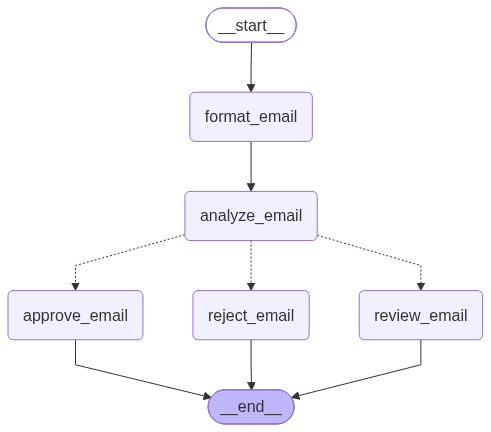

In [5]:
graph = StateGraph(EmailState)

graph.add_node("format_email", format_email)
graph.add_node("analyze_email", analyze_email)
graph.add_node("approve_email", approve_email)
graph.add_node("reject_email", reject_email)
graph.add_node("review_email", review_email)

graph.add_edge(START, "format_email")
graph.add_edge("format_email", "analyze_email")

graph.add_conditional_edges(
    "analyze_email",
    check_email,
    {
        "approve_email": "approve_email",
        "reject_email": "reject_email",
        "review_email": "review_email"
    }
)

graph.add_edge("approve_email", END)
graph.add_edge("reject_email", END)
graph.add_edge("review_email", END)

workflow = graph.compile()
workflow

In [6]:
initial_state = {
    "title" : "promo store",
    "body" : "favorite stuff discount until 70%",
    "from_email" : "new_user"
}

response = workflow.invoke(initial_state)
response

{'title': 'promo store',
 'body': 'favorite stuff discount until 70%',
 'from_email': 'new_user',
 'format_email': 'title: promo store, body: favorite stuff discount until 70%',
 'status_email': 'review',
 'result': 'review, Your email is under review.'}